<a href="https://colab.research.google.com/github/SolJosefinaMercado/AprendizajeAutomatico1/blob/main/AA1_Actividad_caso_estudio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Caso de estudio: preprocesamiento de un dataset y aplicación de clustering

**Ana Laura Diedrichs**

Utilizando solo Numpy y Scikit-learn, y opcionalmente Pandas y Matplotlib, debes realizar  lo siguiente sobre el conjunto de datos de California Housing:

## 1. Descarga y analiza los datos, inspecciona todas las características y el target y  asegúrate de preparar los datos para utilizarse en modelos  predictivos. Puedes hacer el preprocesamiento de características  (selección, transformación) que consideres más adecuado, justificar.





In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("camnugent/california-housing-prices")

print("Path to dataset files:", path)

100%|██████████| 400k/400k [00:00<00:00, 43.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/camnugent/california-housing-prices/versions/1


In [ ]:
! ls /kagglehub/input/california-housing-prices/*

ls: cannot access '/kagglehub/input/california-housing-prices/*': No such file or directory


In [ ]:
import os
import pandas as pd

# List files in the downloaded directory
files_in_path = os.listdir(path)
print(f"Files in {path}: {files_in_path}")

# Find the first CSV file
csv_file = None
for f in files_in_path:
    if f.endswith('.csv'):
        csv_file = os.path.join(path, f)
        break

if csv_file:
    print(f"Loading data from: {csv_file}")
    df = pd.read_csv(csv_file)
    print("DataFrame 'df' created. First 5 rows:")
    display(df.head())
else:
    print("No CSV file found in the downloaded directory.")

Files in /root/.cache/kagglehub/datasets/camnugent/california-housing-prices/versions/1: ['housing.csv']
Loading data from: /root/.cache/kagglehub/datasets/camnugent/california-housing-prices/versions/1/housing.csv
DataFrame 'df' created. First 5 rows:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## **¿ Qué representa cada feature de este dataset?**

Según [el sitio de origen](https://www.kaggle.com/datasets/camnugent/california-housing-prices), nos indica que:

* longitude: representa la longitud geográfica de la ubicación del bloque. Su unidad de medición son los grados decimales.

* latitude: representa la latitud geográfica de la ubicación del bloque. Se mide en grados decimales.

* housing_median_age: es la mediana de la edad de las viviendas situadas dentro de un bloque. Su unidad son los años.

* total_rooms: indica el número total de habitaciones contenidas en todas las viviendas de un bloque. Se mide en unidades (conteo).

* total_bedrooms: indica el número total de dormitorios en todas las viviendas de un bloque. Se mide en unidades (conteo).

* population: representa el número total de personas que residen en las viviendas de un bloque. Su unidad son personas.

* households: es el número total de hogares (grupos de personas que residen en una unidad de vivienda) en un bloque. Se mide en unidades de hogares.

* median_income: representa el ingreso mediano de los hogares dentro de un bloque. Su unidad de medición son decenas de miles de dólares estadounidenses (por ejemplo, un valor de 3 equivale a $30,000 USD).

* median_house_value: es el valor mediano de la vivienda para los hogares dentro de un bloque. Se mide en dólares estadounidenses (USD).

* ocean_proximity: indica la ubicación de la vivienda con respecto al mar. Su unidad es una categoría textual (como "NEAR BAY" o "INLAND").

## Inspeccionando el dataset

Primero, inspeccionaremos el tipo de datos y los valores nulos para entender mejor nuestro dataset.

In [ ]:
import numpy as np

print(df.info())
print("\nValores faltantes por columna:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None

Valores faltantes por columna:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median

Observamos que la columna `total_bedrooms` tiene valores nulos. Para K-means, necesitamos manejar estos valores. Una estrategia común es imputarlos con la mediana.

In [ ]:
# Imputar los valores nulos de 'total_bedrooms' con la mediana
# df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)
# print("Valores nulos después de la imputación:")
# print(df.isnull().sum())

In [ ]:
from sklearn.impute import KNNImputer
import numpy as np

# Instantiate KNNImputer
imputer = KNNImputer(n_neighbors=5)

# Reshape the 'total_bedrooms' column for imputation
# KNNImputer expects a 2D array, even for a single column
df['total_bedrooms'] = imputer.fit_transform(df[['total_bedrooms']])

print("Valores nulos después de la imputación con KNNImputer:")
print(df.isnull().sum())

Valores nulos después de la imputación con KNNImputer:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


Evaluo la correlacion entre las features

### Distribución de Variables Numéricas

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def graficar_histogramas(df:pd.DataFrame):
  # Obtener las columnas numéricas
  numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

  # Crear histogramas para cada variable numérica
  plt.figure(figsize=(18, 4 * len(numerical_cols) // 3 + 4))
  for i, col in enumerate(numerical_cols):
      plt.subplot(len(numerical_cols) // 3 + 1, 3, i + 1)
      sns.histplot(df[col], kde=True, bins=30)
      plt.title(f'Distribución de {col}')
      plt.xlabel(col)
      plt.ylabel('Frecuencia')
      plt.grid(True, linestyle='--', alpha=0.6)

  plt.tight_layout()
  plt.show()


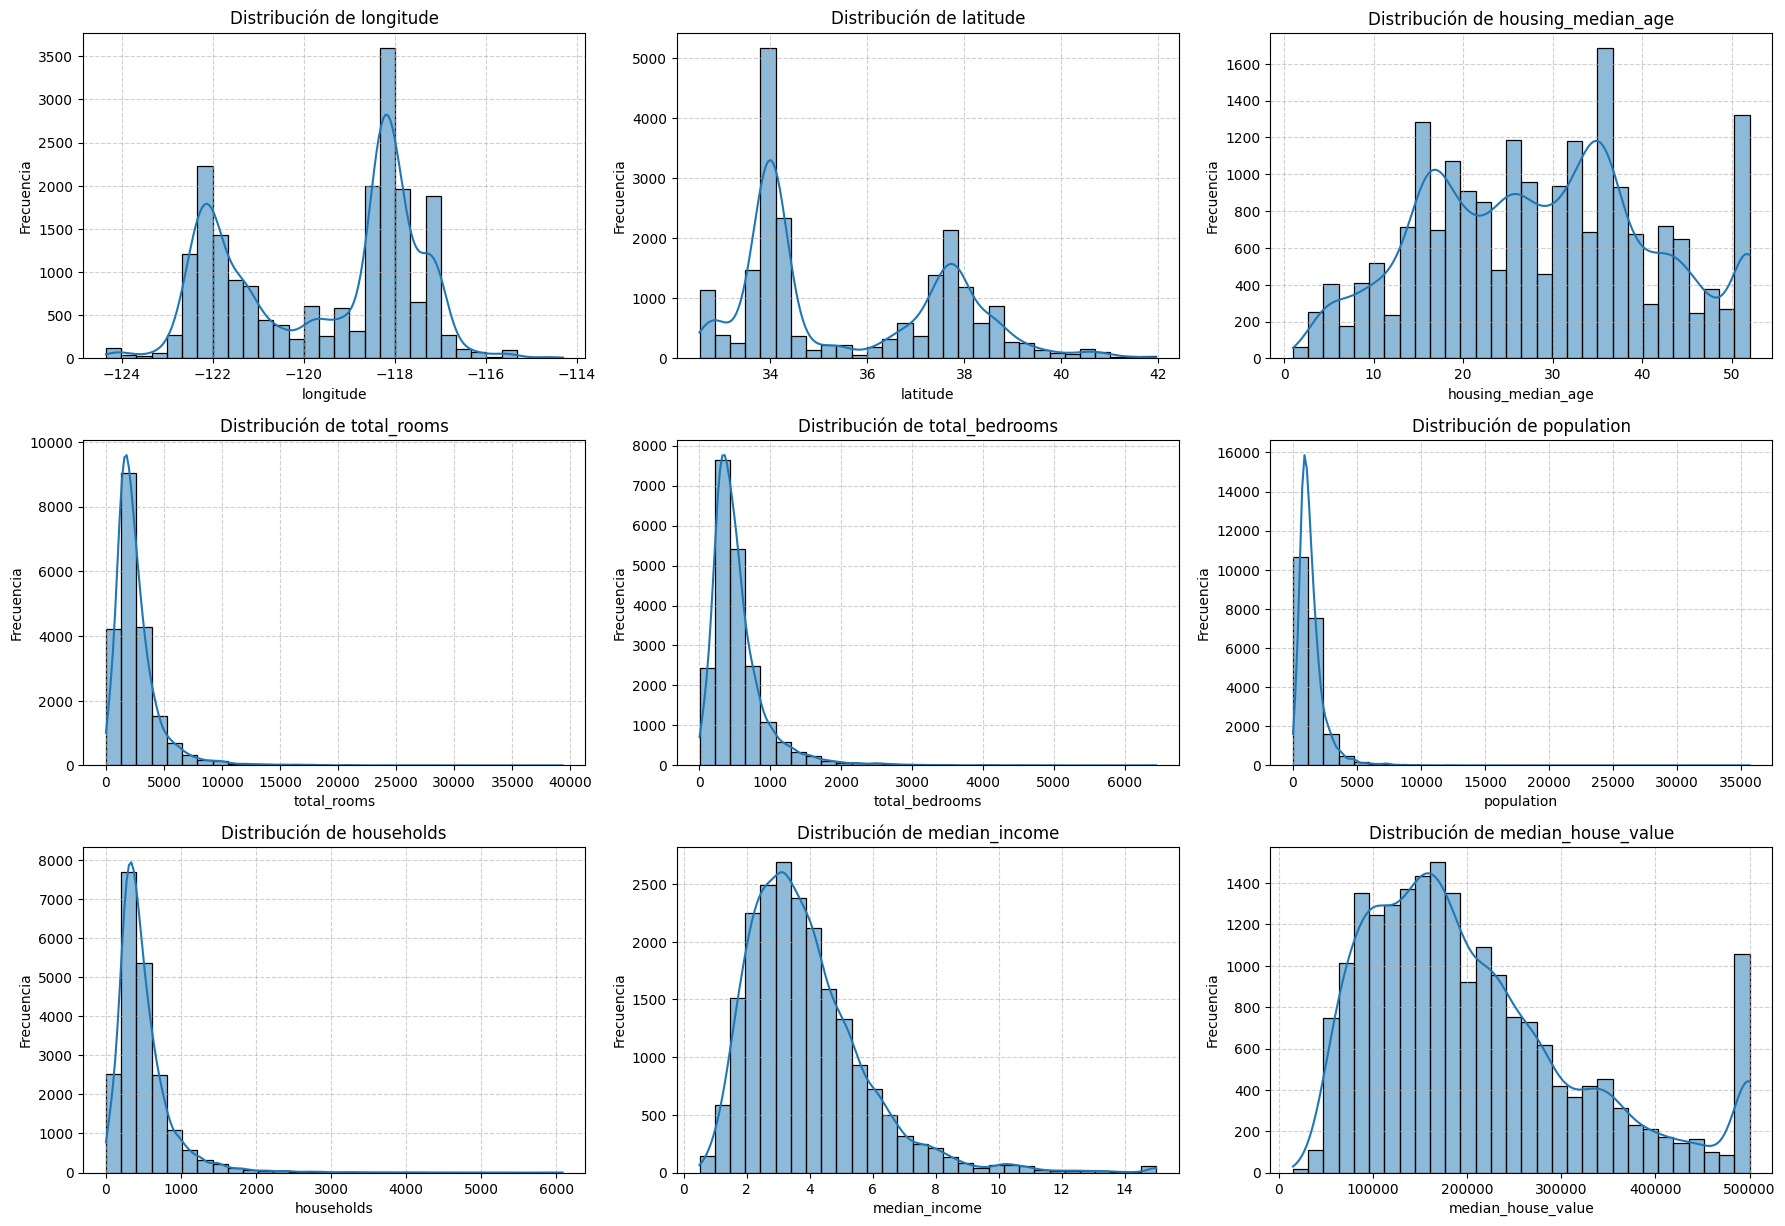

In [ ]:
graficar_histogramas(df)

### Matriz de Correlación de Variables Numéricas

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
def graficar_correlacion(df:pd.DataFrame):
  # Seleccionar solo las columnas numéricas para la correlación
  numerical_df = df.select_dtypes(include=np.number)

  # Calcular la matriz de correlación
  correlation_matrix = numerical_df.corr()

  # Visualizar la matriz de correlación con un mapa de calor
  plt.figure(figsize=(12, 10))
  sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
  plt.title('Matriz de Correlación de Variables Numéricas')
  plt.show()


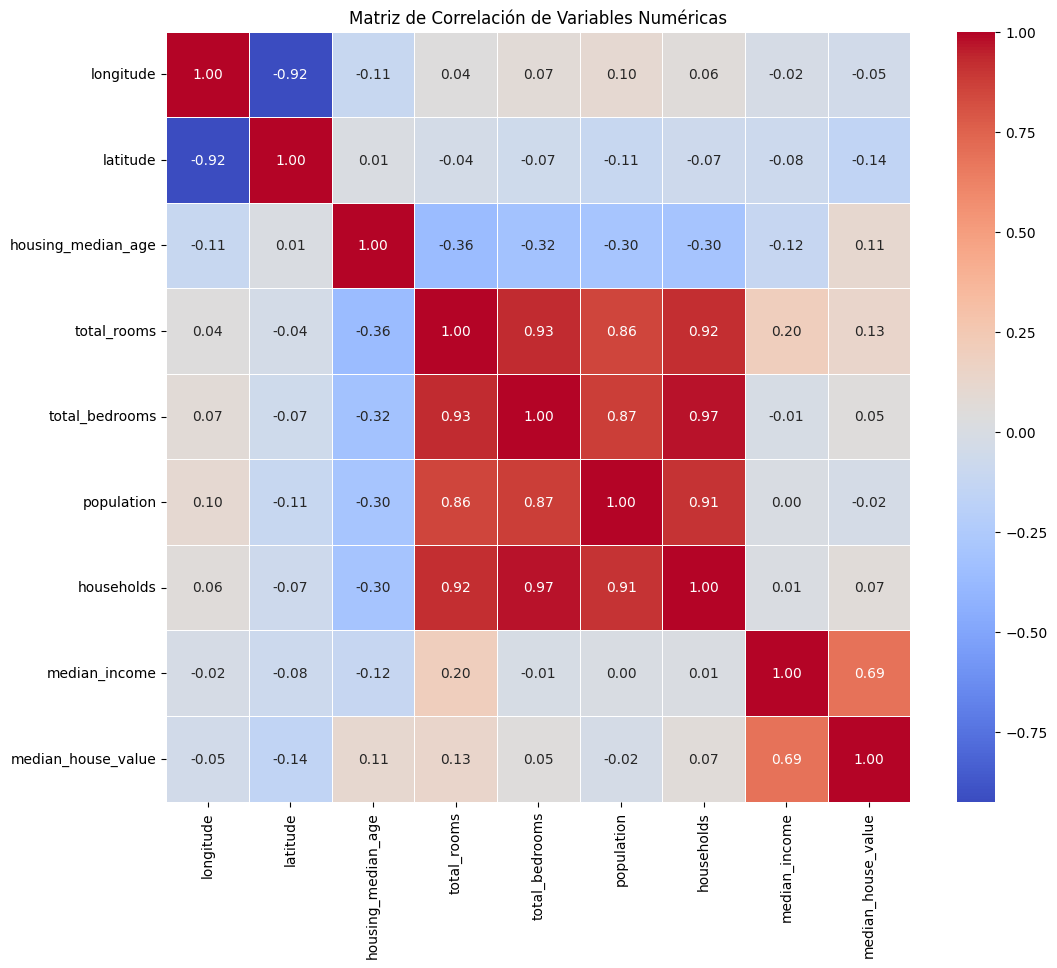

In [ ]:
graficar_correlacion(df)

Es importante considerar que los datos de total_rooms, total_bedrooms, population y households están agregados por bloque.

Para análisis más precisos, procederé a crear nuevas variables como "habitaciones por hogar" o "población por hogar" dividiendo estas cifras por la columna households.

In [ ]:
import numpy as np

# Crear la variable population_per_house
df['population_per_house'] = df['population'] / df['households']

# Crear la variable rooms_per_house
df['rooms_per_house'] = df['total_rooms'] / df['households']

# Eliminar las columnas originales
df.drop(columns=['total_rooms', 'total_bedrooms', 'population', 'households'], inplace=True)

print("Nuevas variables creadas y columnas originales eliminadas.")
print("Primeras 5 filas del DataFrame con las nuevas variables:")
display(df.head())

Nuevas variables creadas y columnas originales eliminadas.
Primeras 5 filas del DataFrame con las nuevas variables:


,longitude,latitude,housing_median_age,median_income,median_house_value,ocean_proximity,population_per_house,rooms_per_house
0,-122.23,37.88,41.0,8.3252,452600.0,NEAR BAY,2.555556,6.984127
1,-122.22,37.86,21.0,8.3014,358500.0,NEAR BAY,2.109842,6.238137
2,-122.24,37.85,52.0,7.2574,352100.0,NEAR BAY,2.802260,8.288136
3,-122.25,37.85,52.0,5.6431,341300.0,NEAR BAY,2.547945,5.817352
4,-122.25,37.85,52.0,3.8462,342200.0,NEAR BAY,2.181467,6.281853


### ocean_proximity



In [ ]:
df["ocean_proximity"].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


Se grafican los valores valores del a categoría ocean_proximity sobre el mapa

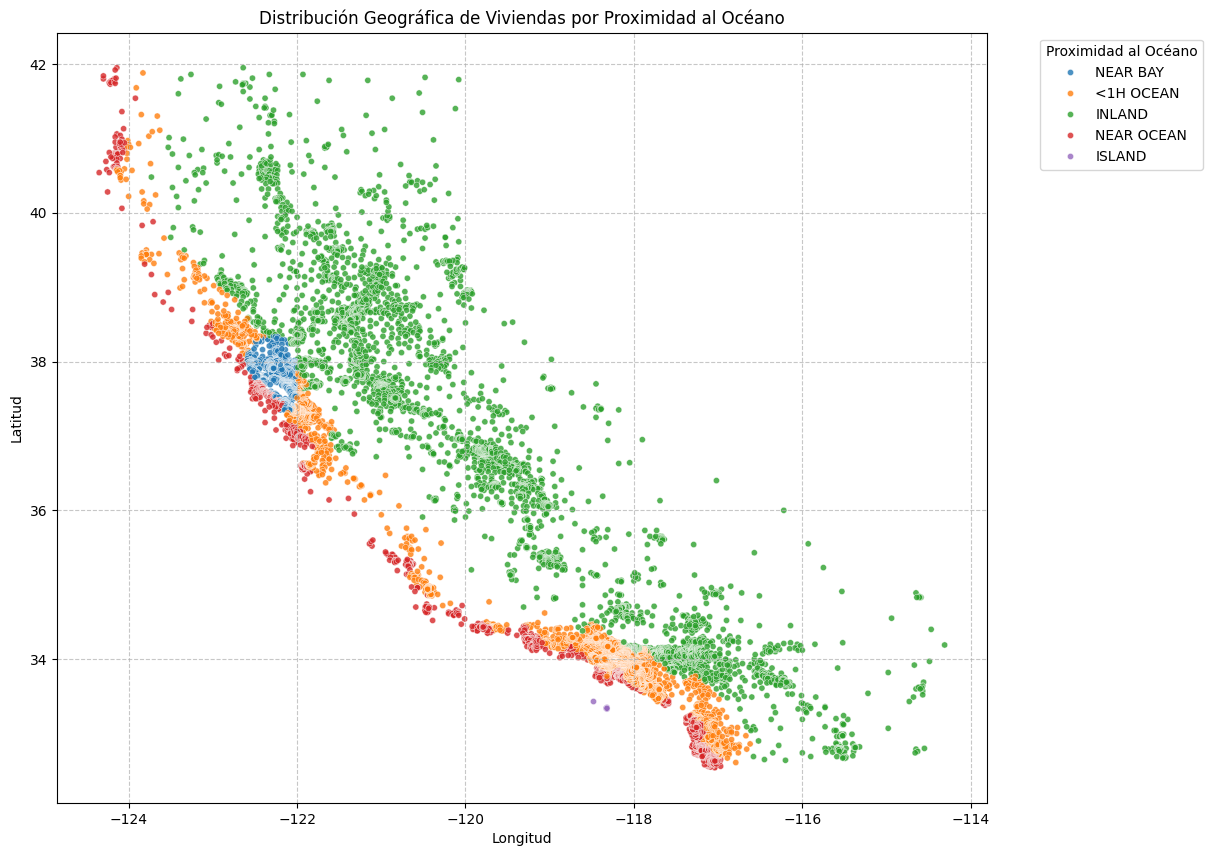

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.scatterplot(x='longitude', y='latitude', hue='ocean_proximity', data=df, palette='tab10', s=20, alpha=0.8)
plt.title('Distribución Geográfica de Viviendas por Proximidad al Océano')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend(title='Proximidad al Océano', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Dado que ocean_proximity sólo me divide la ubicación en áreas, voy a conversar en su lugar a latitud y longitud y quitar ocean_proximity pues la encuentro redundante.

In [ ]:
df.drop("ocean_proximity",axis=1,inplace=True)

In [ ]:
df.head()

,longitude,latitude,housing_median_age,median_income,median_house_value,population_per_house,rooms_per_house
0,-122.23,37.88,41.0,8.3252,452600.0,2.555556,6.984127
1,-122.22,37.86,21.0,8.3014,358500.0,2.109842,6.238137
2,-122.24,37.85,52.0,7.2574,352100.0,2.802260,8.288136
3,-122.25,37.85,52.0,5.6431,341300.0,2.547945,5.817352
4,-122.25,37.85,52.0,3.8462,342200.0,2.181467,6.281853


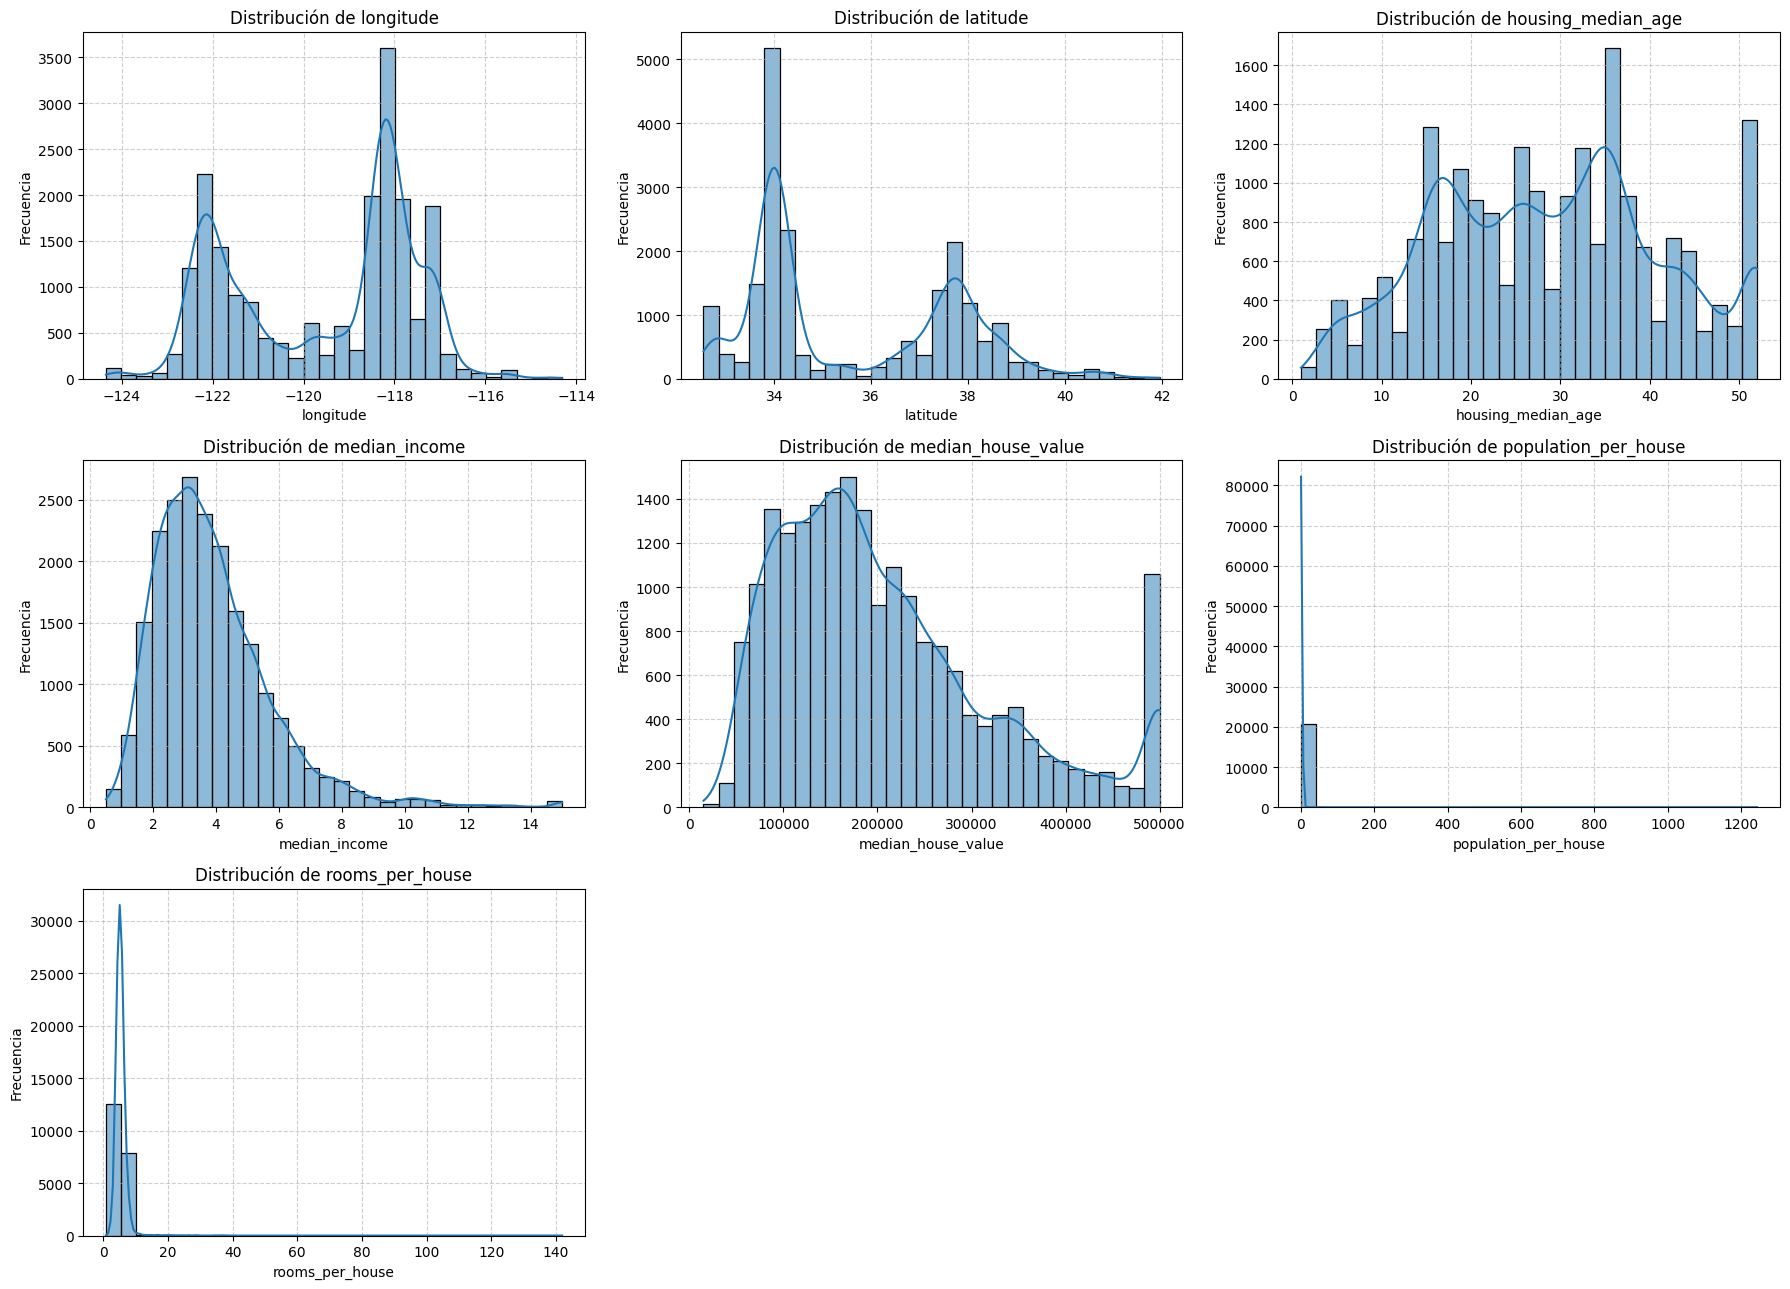

In [ ]:
graficar_histogramas(df)

In [ ]:
df.columns.tolist()



['longitude',
 'latitude',
 'housing_median_age',
 'median_income',
 'median_house_value',
 'population_per_house',
 'rooms_per_house']

Las features median_income, median_house_value , population_per_house, rooms_per_house están sesgadas a la izquierda.

In [ ]:
from sklearn.preprocessing import PowerTransformer
import pandas as pd

df_transform=df.copy()
# Columnas a normalizar
# columns_to_normalize = ['median_income', 'median_house_value', 'population_per_house', 'rooms_per_house']
columns_to_normalize = df.columns.tolist()
# Calcular la asimetría antes de la transformación
skewness_before = df[columns_to_normalize].skew()
print("Asimetría antes de la transformación:\n", skewness_before)

# Inicializar PowerTransformer con el método Yeo-Johnson (maneja valores positivos y negativos)
power_transformer = PowerTransformer(method='yeo-johnson', standardize=False) # standardize=False para mantener la escala original, puede cambiarse a True si también se desea estandarizar aquí

# Aplicar la transformación a las columnas seleccionadas
df_transform[columns_to_normalize] = power_transformer.fit_transform(df_transform[columns_to_normalize])

# Calcular la asimetría después de la transformación
skewness_after = df_transform[columns_to_normalize].skew()
print("\nAsimetría después de la transformación:\n", skewness_after)

print("\nDistribuciones normalizadas para: ", columns_to_normalize)
display(df_transform.head())

Asimetría antes de la transformación:
 longitude               -0.297801
latitude                 0.465953
housing_median_age       0.060331
median_income            1.646657
median_house_value       0.977763
population_per_house    97.639561
rooms_per_house         20.697869
dtype: float64

Asimetría después de la transformación:
 longitude               0.000000
latitude                0.000000
housing_median_age     -0.113089
median_income          -0.002538
median_house_value     -0.012149
population_per_house   -0.106888
rooms_per_house        -0.170146
dtype: float64

Distribuciones normalizadas para:  ['longitude', 'latitude', 'housing_median_age', 'median_income', 'median_house_value', 'population_per_house', 'rooms_per_house']


,longitude,latitude,housing_median_age,median_income,median_house_value,population_per_house,rooms_per_house
0,-0.160757,0.18594,24.133444,1.803599,32.673939,0.755821,1.234372
1,-0.160757,0.18594,13.807367,1.801958,31.507904,0.710445,1.202460
2,-0.160757,0.18594,29.380778,1.724579,31.419191,0.776570,1.280312
3,-0.160757,0.18594,29.380778,1.578385,31.266236,0.755137,1.182107
4,-0.160757,0.18594,29.380778,1.354895,31.279143,0.718551,1.204470


Para comprobar volveré a graficar las distirbuciones

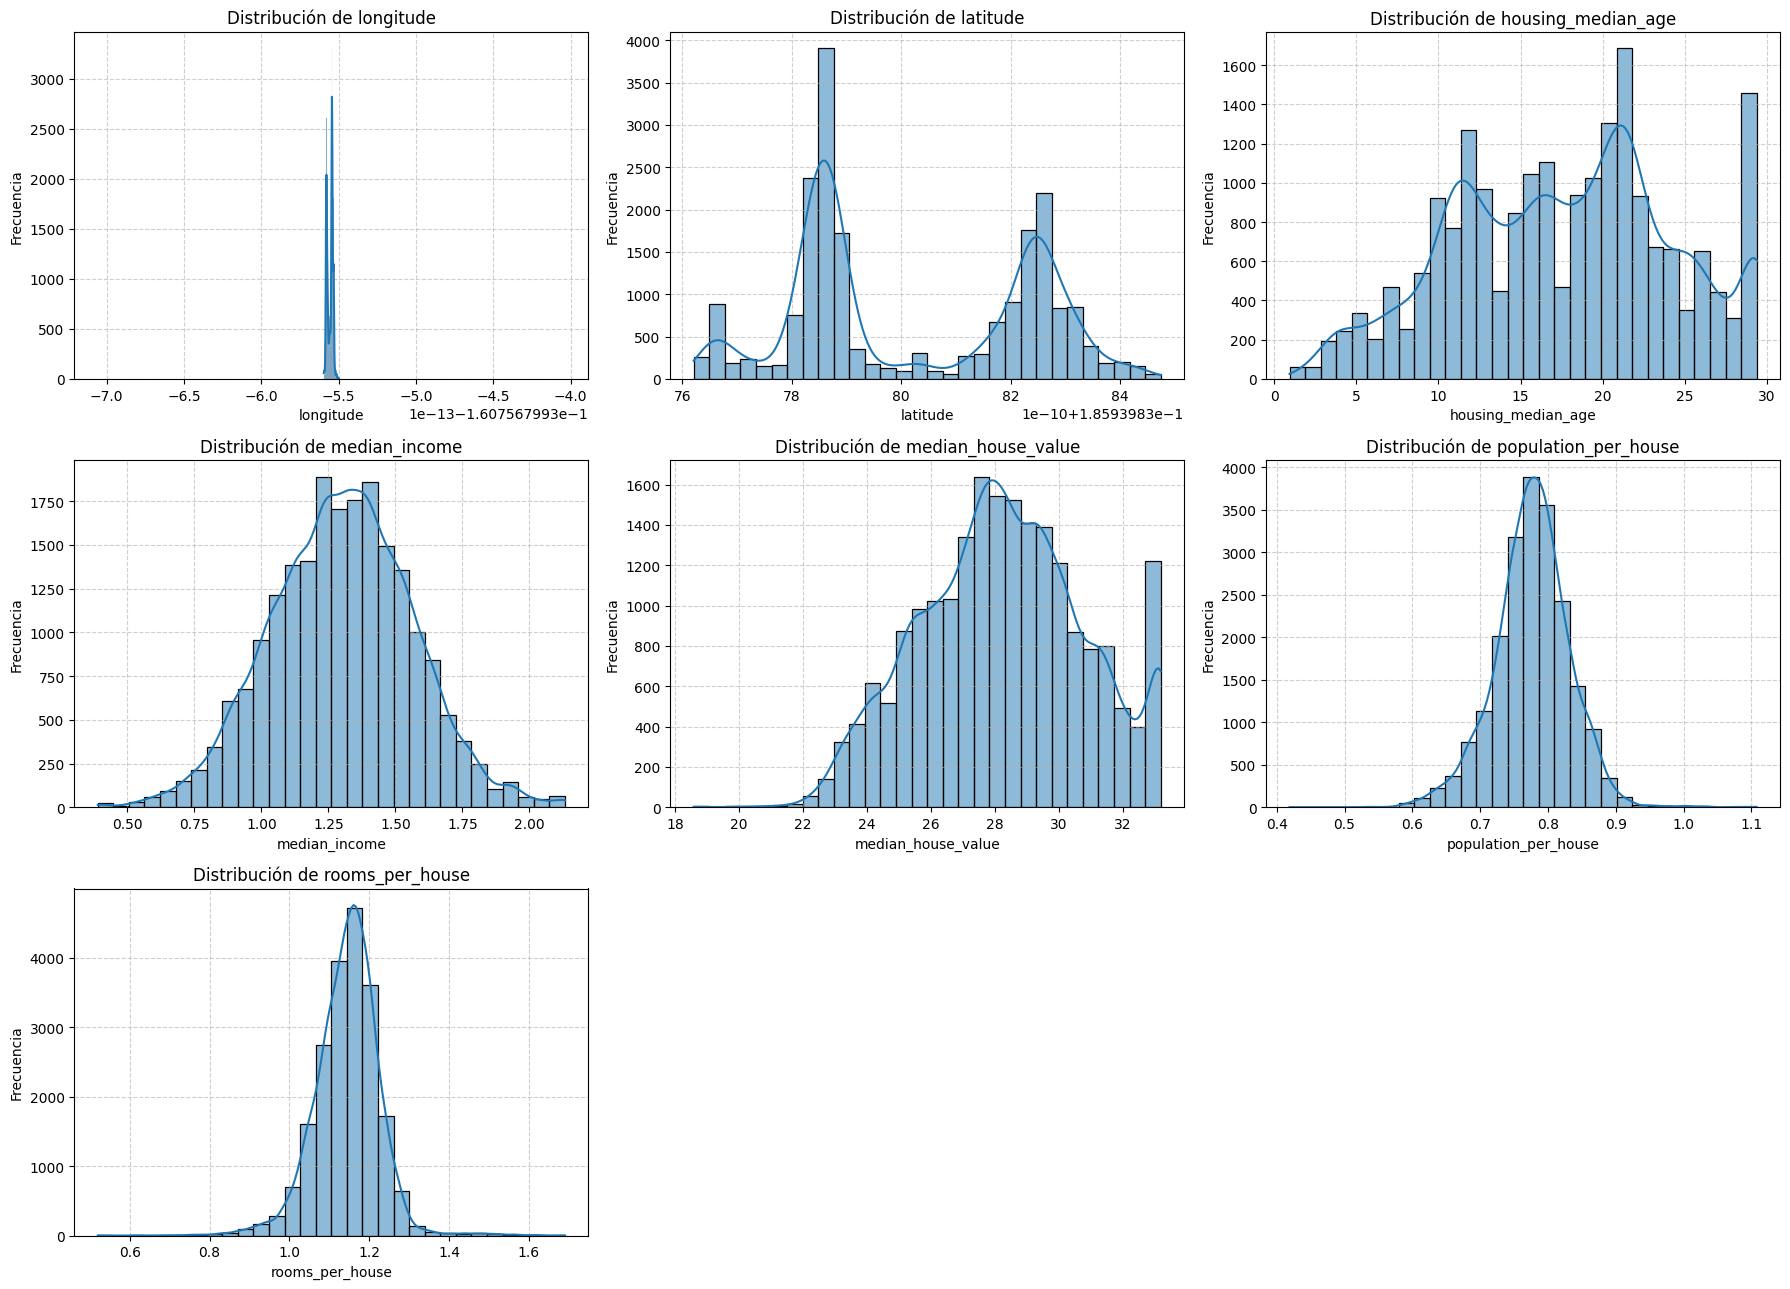

In [ ]:
graficar_histogramas(df_transform)

### features numéricas

Finalmente, escalaremos las características numéricas para que K-means funcione correctamente, ya que es sensible a la escala de los datos.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Identificar columnas numéricas
numerical_cols = df_transform.select_dtypes(include=np.number).columns.tolist()

# Inicializar y aplicar StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_transform[numerical_cols])

# Convertir a DataFrame para mantener los nombres de las columnas
X_scaled_df = pd.DataFrame(X_scaled, columns=numerical_cols)

print("Primeras 5 filas del DataFrame después del escalado:")
display(X_scaled_df.head())

Primeras 5 filas del DataFrame después del escalado:


,longitude,latitude,housing_median_age,median_income,median_house_value,population_per_house,rooms_per_house
0,-2.414735e-15,1.089037,0.975968,1.903289,1.718078,-0.368763,1.106394
1,-2.414735e-15,1.082404,-0.568893,1.897081,1.262941,-1.186265,0.712367
2,-2.414735e-15,1.079079,1.761010,1.604361,1.228314,0.005053,1.673645
3,-2.414735e-15,1.079079,1.761010,1.051321,1.168611,-0.381080,0.461045
4,-2.414735e-15,1.079079,1.761010,0.205878,1.173649,-1.040230,0.737176


## Aplicando K-means Clustering

Ahora aplicaremos K-means para diferentes valores de `k` (de 2 a 10) y calcularemos la inercia para cada uno. Esto nos ayudará a encontrar el número óptimo de clusters usando el método del codo.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Lista para almacenar los valores de inercia y silhouette score
inertia_values = []
silhouette_scores = []

# Rango de k a probar
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled_df)
    inertia_values.append(kmeans.inertia_)

    # Calcular Silhouette Score

    score = silhouette_score(X_scaled_df, kmeans.labels_)
    silhouette_scores.append(score)


print("Valores de inercia para cada k (de 2 a 10):", inertia_values)
print("Valores de Silhouette Score para cada k (de 2 a 10):", silhouette_scores)

Valores de inercia para cada k (de 2 a 10): [96381.04247434241, 83027.16516073911, 72820.51135437941, 66057.68558568433, 61118.59492210622, 56809.693014882534, 53418.06189428637, 51027.82875314917, 48710.81730301838]
Valores de Silhouette Score para cada k (de 2 a 10): [np.float64(0.20028295319817083), np.float64(0.19777052651129354), np.float64(0.20038386194488125), np.float64(0.19870505863581966), np.float64(0.19373124836118732), np.float64(0.1863967243487724), np.float64(0.19066909194940415), np.float64(0.18524867684128102), np.float64(0.18744640418088365)]


### Visualización de métricas y conclusión

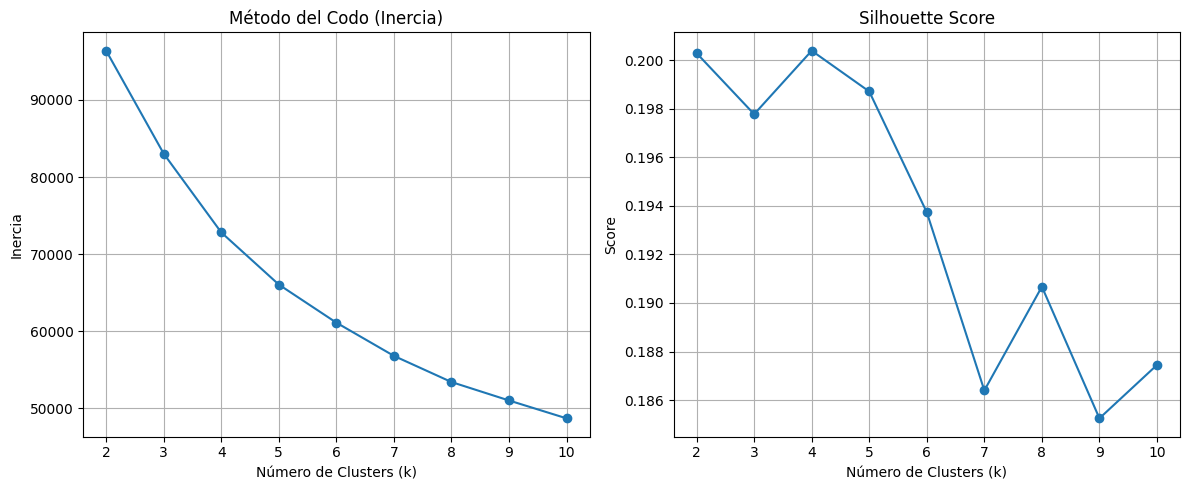

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

k_range = range(2, 11)

# Graficar Inercia (Método del Codo)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia_values, marker='o', linestyle='-')
plt.title('Método del Codo (Inercia)')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.xticks(k_range)
plt.grid(True)

# Graficar Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o', linestyle='-')
plt.title('Silhouette Score')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Score')
plt.xticks(k_range)
plt.grid(True)

plt.tight_layout()
plt.show()

### Conclusión sobre el número óptimo de clusters

Basándonos en los gráficos de inercia (método del codo) y Silhouette Score, podemos analizar el número óptimo de clusters:

*   **Método del Codo (Inercia):** Buscamos el punto donde la curva de inercia deja de disminuir significativamente, formando un 'codo'. Observando la gráfica, parece que hay una disminución notable de la inercia hasta aproximadamente `k=4` o `k=5`, después de lo cual la tasa de disminución se ralentiza.

*   **Silhouette Score:** Un Silhouette Score más alto indica una mejor separación de los clusters. En este caso, el Silhouette Score es más alto para `k=2` y `k=4`, y luego disminuye para valores mayores de `k`.

Es importante notar que el Silhouette Score disminuye para `k` mayores a 5, lo que sugiere que para este dataset los clusters pueden no estar muy bien definidos y separados.


Considerando ambos, **k=4** es un buen candidato. Para una decisión final, sería útil explorar la interpretabilidad de los clusters formados por `k=4` y ver si tienen sentido en el contexto del problema.

### Entrenar K-means con un valor de K y asignar clusterres

In [ ]:
from sklearn.cluster import KMeans

# Entrenar el modelo K-means un determinado valor de k
k_optimal = 4
kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
kmeans_final.fit(X_scaled_df)

# Asignar las etiquetas de los clusters al DataFrame original
df['cluster'] = kmeans_final.labels_

print(f"Modelo K-means entrenado con {k_optimal} clusters.")
print("Primeras 5 filas del DataFrame original con las etiquetas de cluster:")
display(df.head())

Modelo K-means entrenado con 4 clusters.
Primeras 5 filas del DataFrame original con las etiquetas de cluster:


,longitude,latitude,housing_median_age,median_income,median_house_value,population_per_house,rooms_per_house,cluster
0,-122.23,37.88,41.0,8.3252,452600.0,2.555556,6.984127,3
1,-122.22,37.86,21.0,8.3014,358500.0,2.109842,6.238137,3
2,-122.24,37.85,52.0,7.2574,352100.0,2.802260,8.288136,3
3,-122.25,37.85,52.0,5.6431,341300.0,2.547945,5.817352,1
4,-122.25,37.85,52.0,3.8462,342200.0,2.181467,6.281853,1


## Análisis descriptivo de cada clúster

### Estadísticas descriptivas de cada clúster

In [ ]:

cluster_description = df.groupby('cluster').describe()
print("Análisis estadístico descriptivo por cluster:")
display(cluster_description)

Análisis estadístico descriptivo por cluster:


longitude                                                        \
            count        mean       std     min     25%     50%     75%   
cluster                                                                   
0          4931.0 -118.155500  1.143776 -124.07 -118.29 -118.16 -117.64   
1          4477.0 -119.726390  2.044785 -122.87 -122.14 -118.43 -118.14   
2          5227.0 -120.990069  1.576354 -124.35 -122.08 -121.31 -119.98   
3          6005.0 -119.377817  1.997641 -124.05 -121.84 -118.42 -117.81   

                latitude             ... population_per_house               \
            max    count       mean  ...                  75%          max   
cluster                              ...                                     
0       -114.55   4931.0  34.075129  ...             4.133785  1243.333333   
1       -114.62   4477.0  35.332602  ...             2.494709     3.743421   
2       -114.31   5227.0  37.804115  ...             3.086564    10.153846   
3       -114.49   6005.0  35.242463  ...             3.194203   230.172414   

        rooms_per_house                                                    \
                  count      mean       std       min       25%       50%   
cluster                                                                     
0                4931.0  4.343272  0.870110  0.888889  3.786331  4.350746   
1                4477.0  4.697909  0.872967  0.846154  4.125370  4.714908   
2                5227.0  5.431100  1.856066  2.000000  4.744752  5.268730   
3                6005.0  6.863777  3.664564  3.157895  5.841912  6.390845   

                               
              75%         max  
cluster                        
0        4.927708    9.076923  
1        5.283636    8.564179  
2        5.795082   59.875000  
3        7.127717  141.909091  

[4 rows x 56 columns]

### Distribución geográfica de los clústeres

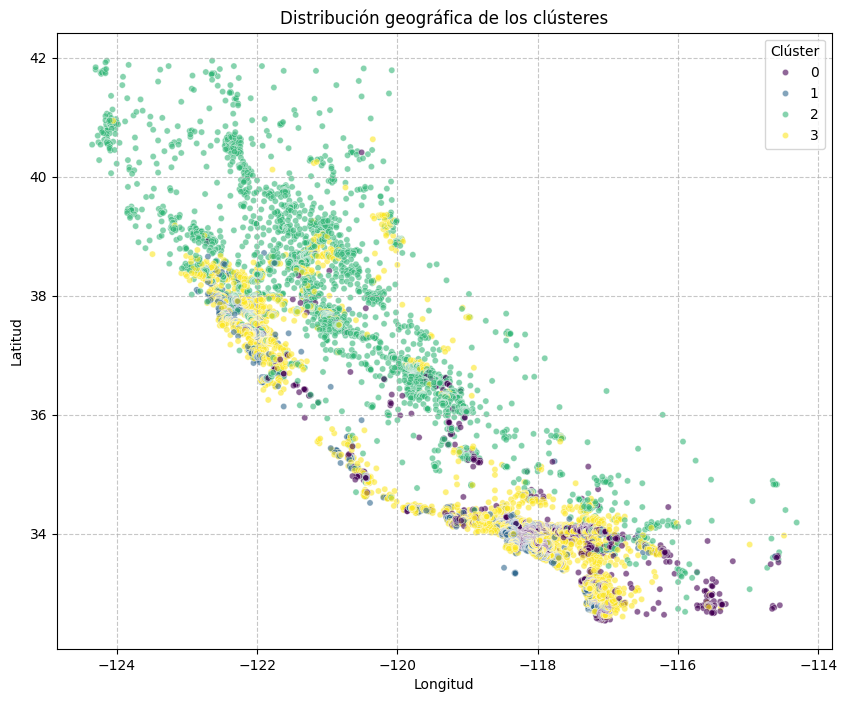

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.scatterplot(x='longitude', y='latitude', hue='cluster', data=df, palette='viridis', s=20, alpha=0.6)
plt.title('Distribución geográfica de los clústeres')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend(title='Clúster')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Análisis de dispersión por cluster (boxplots)

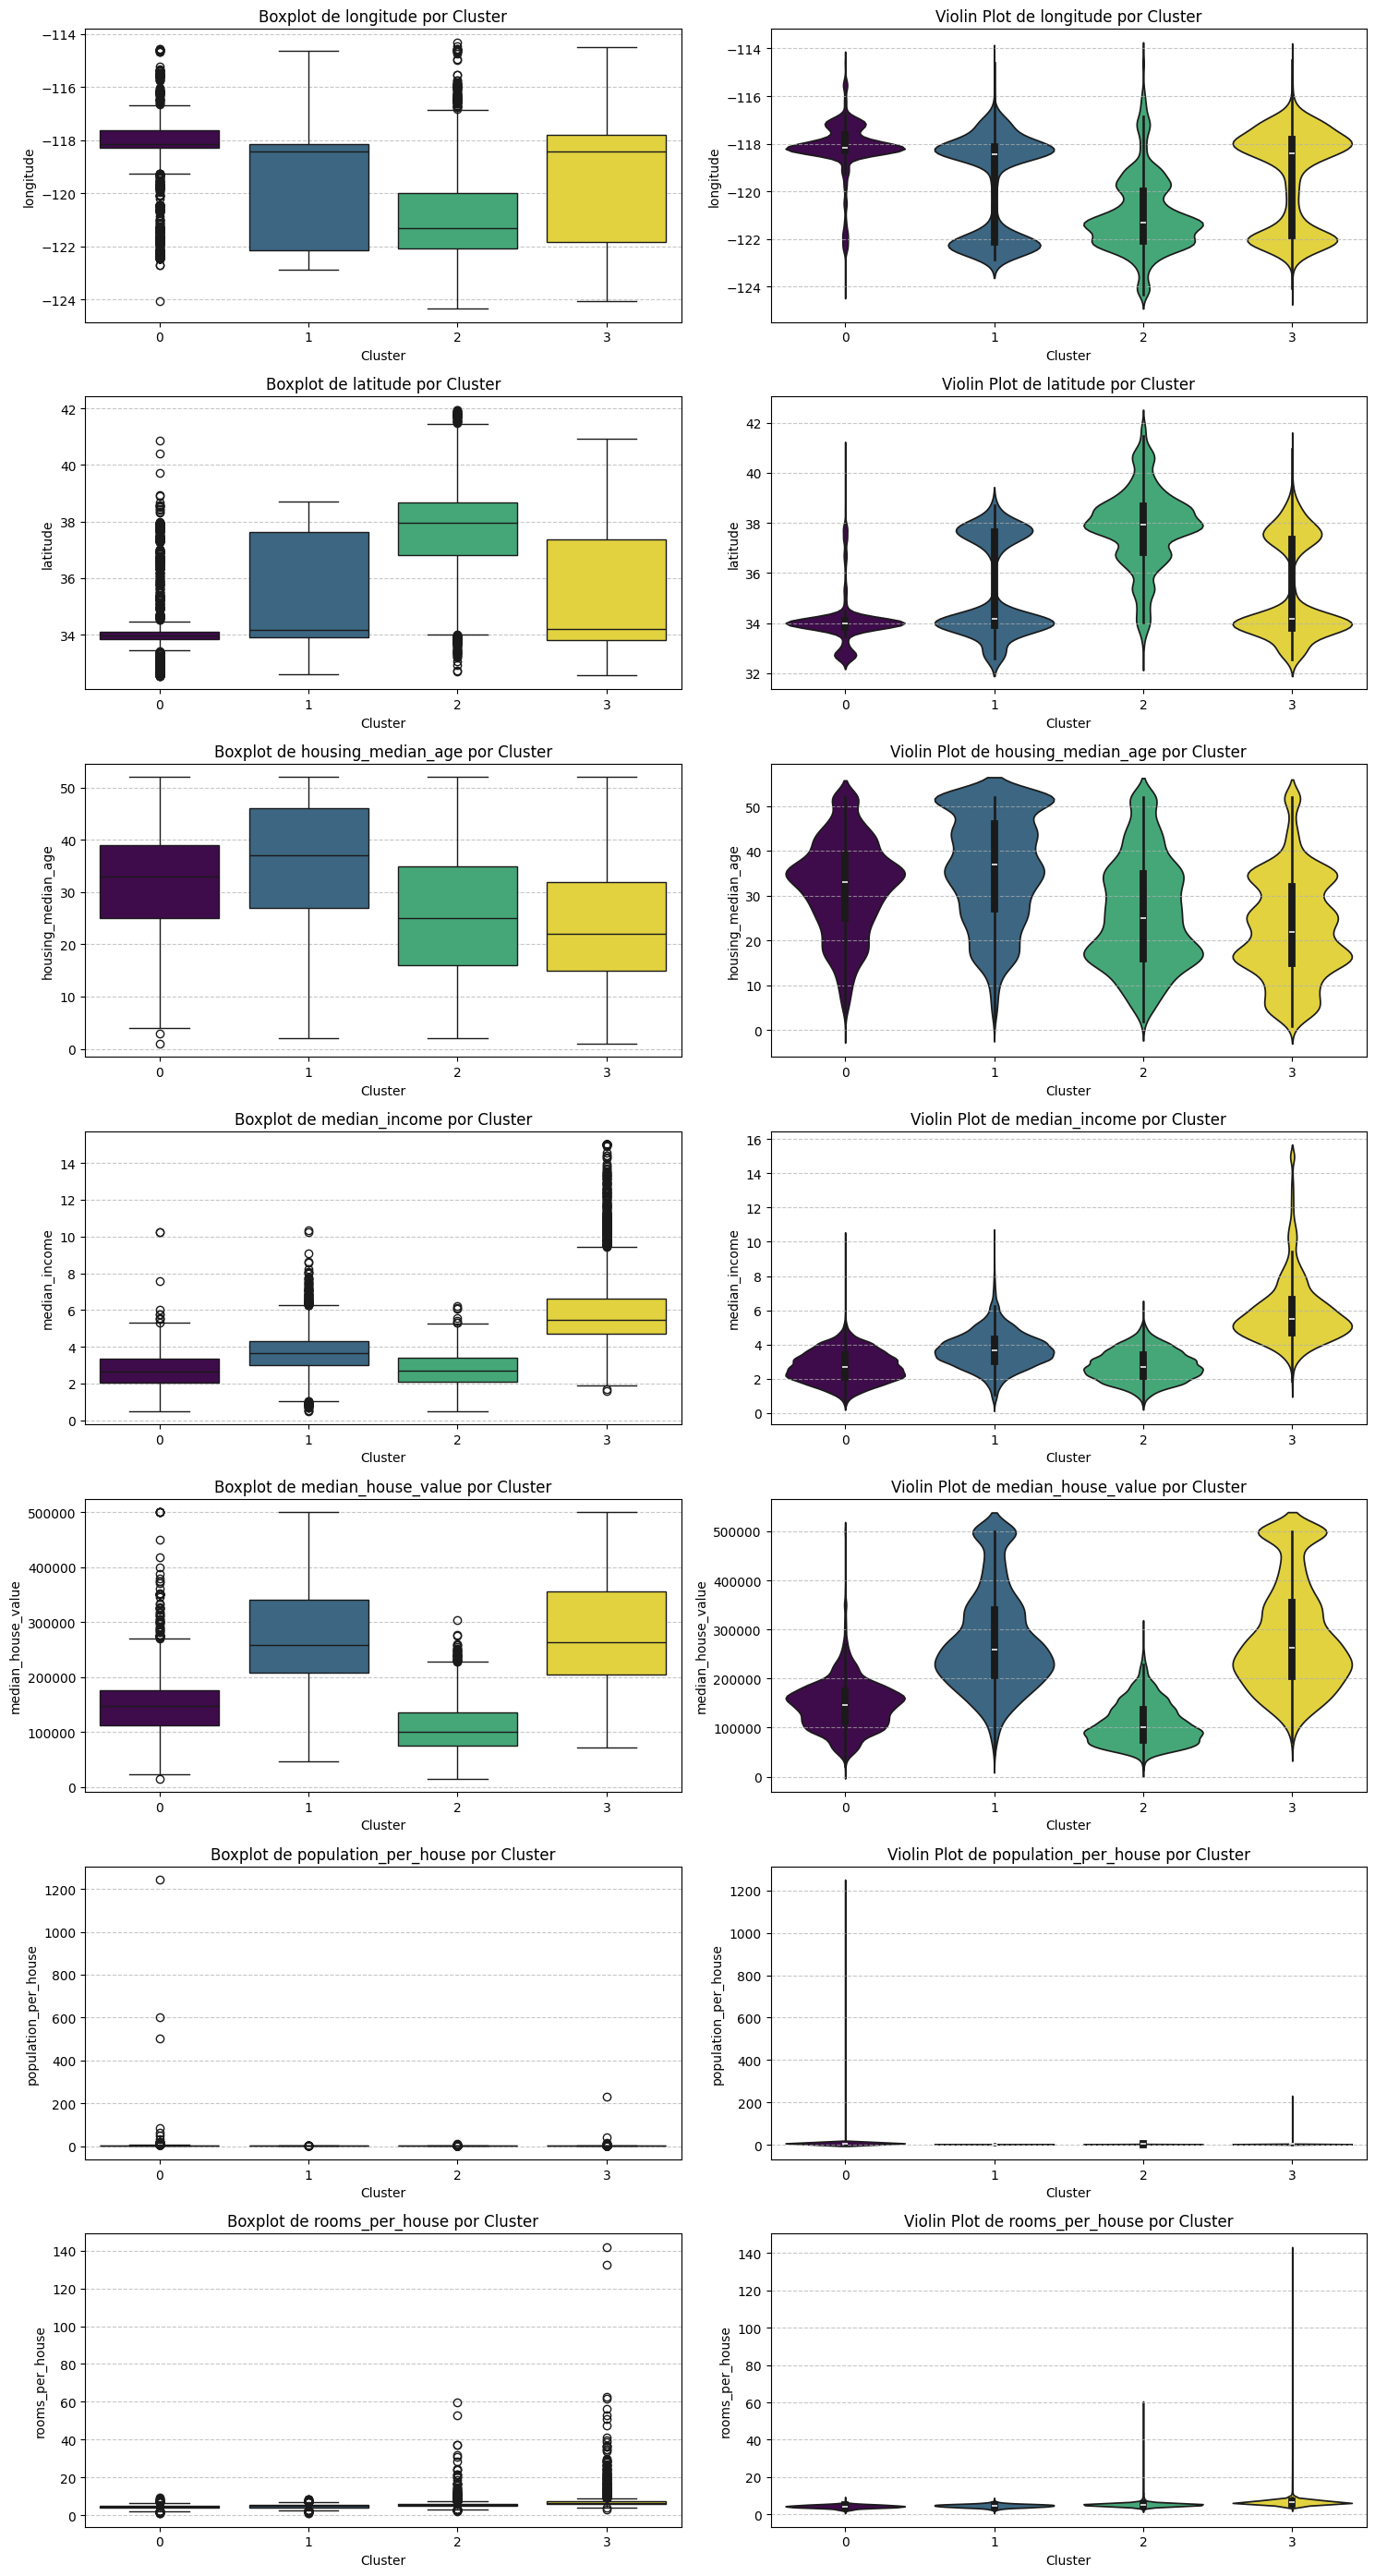

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Obtener las columnas numéricas, menos la de cluster 'cluster'
numerical_features = df.select_dtypes(include=np.number).columns.tolist()
numerical_features.remove('cluster') # se quita la columna cluster

# Creamos un boxplot para cada feature para analizar su dispersión frente a cada valor de cluster
plt.figure(figsize=(15, 4 * len(numerical_features)))
for i, feature in enumerate(numerical_features):
    plt.subplot(len(numerical_features), 2, 2*i + 1) # Crea subplots ordenados en dos columnas
    sns.boxplot(x='cluster', y=feature, data=df, hue='cluster', palette='viridis', legend=False)
    plt.title(f'Boxplot de {feature} por Cluster')
    plt.xlabel('Cluster')
    plt.ylabel(feature)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Opcional, mostrar gráfico violín para ver la dispersión
    plt.subplot(len(numerical_features), 2, 2*i + 2)
    sns.violinplot(x='cluster', y=feature, data=df, hue='cluster', palette='viridis', legend=False)
    plt.title(f'Violin Plot de {feature} por Cluster')
    plt.xlabel('Cluster')
    plt.ylabel(feature)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Interpretación de los clústeres

Basándonos en los boxplots, violin plots y las estadísticas descriptivas por clúster (`cluster_description`), podemos caracterizar cada uno de los cuatro clústeres:

**Clúster 0:**
*   **Longitud y Latitud:** Este clúster se ubica principalmente en el noreste de la región, con latitudes más altas y longitudes más bajas en comparación con la media general. Sugiere una ubicación más al norte de la bahía.
*   **Edad Media de la Vivienda:** Tiende a tener viviendas más nuevas, con una `housing_median_age` relativamente baja.
*   **Ingreso Mediano (`median_income`):** Presenta ingresos medianos más altos, lo que indica zonas con mayor poder adquisitivo.
*   **Valor Mediano de la Vivienda (`median_house_value`):** Tiene valores de vivienda significativamente más altos, coherente con los ingresos más elevados.
*   **Población por Hogar y Habitaciones por Hogar:** Muestra una densidad de población por hogar moderada y un número de habitaciones por hogar también moderado. Esto puede indicar viviendas unifamiliares o condominios más espaciosos.

**Clúster 1:**
*   **Longitud y Latitud:** Este clúster se localiza predominantemente en el centro de la región, abarcando áreas geográficas diversas.
*   **Edad Media de la Vivienda:** Las viviendas en este clúster tienen una edad media en el rango intermedio, ni muy nuevas ni muy antiguas.
*   **Ingreso Mediano:** Los ingresos medianos son más bajos en comparación con el Clúster 0 y 3, sugiriendo áreas con un nivel socioeconómico medio-bajo.
*   **Valor Mediano de la Vivienda:** Los valores de las viviendas son los más bajos entre todos los clústeres.
*   **Población por Hogar y Habitaciones por Hogar:** Este clúster se caracteriza por una mayor población por hogar y un menor número de habitaciones por hogar, lo que podría indicar viviendas más densas o apartamentos con menos espacio por persona.

**Clúster 2:**
*   **Longitud y Latitud:** Se concentra en la parte suroeste de la región. Esto sugiere áreas cercanas a la costa sur.
*   **Edad Media de la Vivienda:** Similar al Clúster 1, con una `housing_median_age` en el rango medio.
*   **Ingreso Mediano:** Los ingresos medianos son relativamente bajos, similar al Clúster 1.
*   **Valor Mediano de la Vivienda:** El valor de las viviendas también es bajo, similar al Clúster 1. Sin embargo, su ubicación geográfica es distintiva.
*   **Población por Hogar y Habitaciones por Hogar:** Muestra una población por hogar en el rango medio y habitaciones por hogar también en el rango medio, lo que indica un equilibrio.

**Clúster 3:**
*   **Longitud y Latitud:** Se encuentra en la parte noroeste de la región, con longitudes más bajas y latitudes más altas, lo que indica zonas costeras o cercanas al mar en la parte norte.
*   **Edad Media de la Vivienda:** Presenta las viviendas más antiguas, con una `housing_median_age` consistentemente alta.
*   **Ingreso Mediano:** Tiene ingresos medianos altos, comparable al Clúster 0.
*   **Valor Mediano de la Vivienda:** Los valores de las viviendas son los segundos más altos, después del Clúster 0.
*   **Población por Hogar y Habitaciones por Hogar:** Tiene una baja población por hogar y un alto número de habitaciones por hogar, lo que puede indicar viviendas grandes con menor densidad de ocupación, posiblemente zonas residenciales de lujo o propiedades más grandes con pocos ocupantes.

| Característica                     | Clúster 0                                                               | Clúster 1                                                                  | Clúster 2                                                               | Clúster 3                                                              |
| :--------------------------------- | :---------------------------------------------------------------------- | :------------------------------------------------------------------------- | :---------------------------------------------------------------------- | :--------------------------------------------------------------------- |
| **Ubicación Geográfica**           | Noreste (latitudes más altas, longitudes más bajas)                     | Centro de la región (áreas geográficas diversas)                          | Suroeste (cerca de la costa sur)                                        | Noroeste (longitudes más bajas, latitudes más altas, zonas costeras)   |
| **Edad Media de la Vivienda**      | Relativamente nueva (baja `housing_median_age`)                         | Rango intermedio (ni muy nuevas ni muy antiguas)                           | Rango intermedio (similar al Clúster 1)                               | Más antiguas (consistentemente alta `housing_median_age`)              |
| **Ingreso Mediano**                | Alto                                                                    | Bajo a medio-bajo                                                          | Bajo                                                                    | Alto (comparable al Clúster 0)                                         |
| **Valor Mediano de la Vivienda**   | Significativamente alto                                                 | Más bajo entre todos los clústeres                                         | Bajo (similar al Clúster 1)                                             | Segundo más alto (después del Clúster 0)                               |
| **Población por Hogar**            | Moderada                                                                | Mayor                                                                      | Media                                                                   | Baja                                                                   |
| **Habitaciones por Hogar**         | Moderadas (viviendas unifamiliares o condominios más espaciosos)        | Menor (viviendas más densas o apartamentos con menos espacio por persona) | Media (equilibrio)                                                      | Alta (viviendas grandes con menor densidad de ocupación)               |
| **Perfil General**                 | Zonas con mayor poder adquisitivo, viviendas nuevas, en el noreste.     | Áreas socioeconómicas medio-bajas, con viviendas más densas en el centro.  | Áreas socioeconómicas bajas en el suroeste, con ubicación distintiva.   | Zonas residenciales de lujo o propiedades grandes y antiguas en el noroeste.

# Conclusiones

He notado que las nuevas variables (features) creadas tenían valores extremos. Se podría considerar un análisis sobre ellas y considerar que sucedería si se eliminan o no dichos valores. Sin embargo para no perder información, en este trabajo decidí no eliminar ningún valor extremo.

El análisis de cada clúster nos ayuda a encontrar grupos con altos ingresos y hogares caros (ejemplo clúster 3). También a identificar las ubicaciones geográficas relacionadas con las propiedades más costosas (área de la bahía de San Francisco, grandes zonas urbanas, la costa). En cambio, las viviendas más nuevas y baratas se observan en el clúster dos, también relacionada con una población de menor ingresos.